# OPTICS
## Key Points
- Density-based: Like DBSCAN, it groups points that are closely packed together.
- Reachability distance: A measure of how easily one point can be reached from another, considering local density.
- Cluster ordering: OPTICS doesn’t directly assign clusters; it produces an ordering that reveals the clustering structure.
- Flexibility: From this ordering, clusters of varying densities can be identified without re-running the algorithm with different parameters.

Simple Contrast
- DBSCAN: Needs a fixed eps (radius) → struggles with clusters of different densities.
- OPTICS: Builds a reachability plot → allows clusters to be extracted at multiple density thresholds.

👉 In short: OPTICS is like DBSCAN’s smarter cousin — it doesn’t lock you into one density level, but instead gives you a full picture of the clustering structure.
## سادہ الفاظ میں فرق
- DBSCAN: آپ کو پہلے سے ایک فاصلہ دینا پڑتا ہے۔ (eps) اسی فاصلے کے اندر موجود پوائنٹس کو ایک گروپ میں ڈال دیتا ہے۔
- OPTICS: یہ ایک لمبی لسٹ بناتا ہے جس میں دکھاتا ہے کہ کون سا پوائنٹ کس دوسرے پوائنٹ تک کتنی آسانی سے پہنچ سکتا ہے۔ اس لسٹ سے آپ مختلف گروپس نکال سکتے ہیں، چاہے ان کی کثافت (density) 

## مثال
سوچیں آپ کے پاس ایک شہر کا نقشہ ہے:
- DBSCAN کہتا ہے: "جو لوگ 500 میٹر کے اندر ہیں وہ ایک گروپ ہیں۔"
- OPTICS کہتا ہے: "میں سب لوگوں کو ایک ترتیب میں رکھوں گا، پھر آپ دیکھ سکتے ہیں کہ کہاں لوگ زیادہ قریب ہیں (کلسٹر) اور کہاں دور ہیں (خالی جگہ)۔"


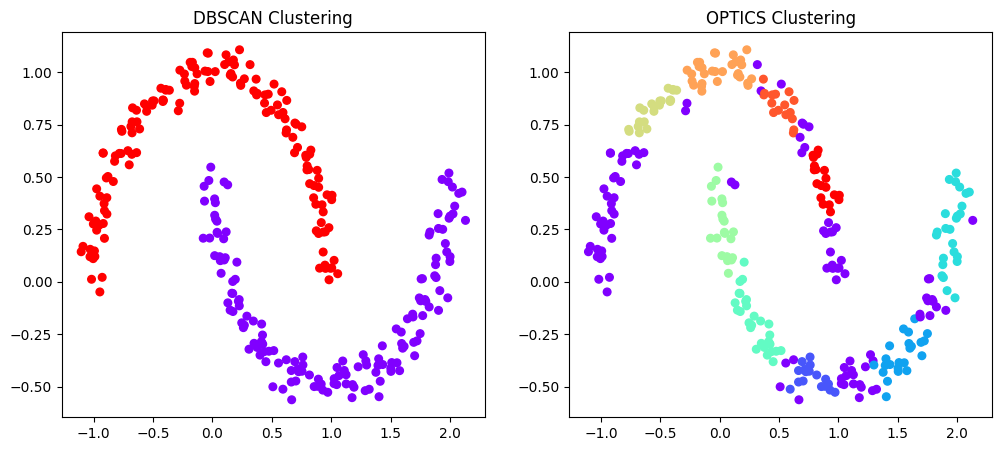

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN, OPTICS

# 1. Create a toy dataset
X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

# 2. Apply DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels_db = dbscan.fit_predict(X)

# 3. Apply OPTICS
optics = OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.05)
labels_optics = optics.fit_predict(X)

# 4. Plot results
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(X[:,0], X[:,1], c=labels_db, cmap='rainbow', s=30)
axs[0].set_title("DBSCAN Clustering")

axs[1].scatter(X[:,0], X[:,1], c=labels_optics, cmap='rainbow', s=30)
axs[1].set_title("OPTICS Clustering")

plt.show()